# CLIP Fine-Tuning V2 - Egypt Landmarks
**Memory-optimized version with:**
- Mixed precision (FP16) training
- Gradient accumulation
- Proper trainable linear classifier head
- Data augmentation
- Learning rate scheduler with warmup
- Early stopping

In [1]:
!pip install -q torch torchvision transformers open_clip_torch pillow matplotlib pandas tqdm scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as T
from PIL import Image
import open_clip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from collections import Counter
import warnings
import gc
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [3]:
# Setup paths - Kaggle
DATASET_PATH = Path('/kaggle/input/updated-landmark-data/images')
SAVE_DIR = Path('/kaggle/working/clip_egypt_models_v2')
SAVE_DIR.mkdir(exist_ok=True, parents=True)

# Memory-optimized config
CONFIG = {
    'min_images': 15,
    'batch_size': 4,            # Reduced for memory
    'accumulation_steps': 4,    # Effective batch = 8 * 4 = 32
    'epochs': 50,
    'lr': 2e-5,
    'warmup_epochs': 2,
    'patience': 8,
    'clip_model': 'ViT-L-14',   # Large model with memory optimizations
    'pretrained': 'openai',
    'num_workers': 0,
    'unfreeze_layers': 6,
    'use_amp': True,            # Mixed precision for memory savings
}

In [4]:
# Load all classes
all_classes = {}
for folder in sorted(DATASET_PATH.iterdir()):
    if folder.is_dir():
        imgs = [f for f in folder.iterdir() if f.suffix.lower() in ['.jpg','.jpeg','.png','.webp']]
        if len(imgs) >= CONFIG['min_images']:
            all_classes[folder.name] = imgs

class_names = sorted(all_classes.keys())
class_to_idx = {n: i for i, n in enumerate(class_names)}
num_classes = len(class_names)

class_counts = {c: len(imgs) for c, imgs in all_classes.items()}
total_images = sum(class_counts.values())
print(f"Classes: {num_classes}, Total images: {total_images}")
print(f"Avg images/class: {total_images/num_classes:.1f}")

Classes: 110, Total images: 4342
Avg images/class: 39.5


In [5]:
# Build dataset
data = [{'path': str(p), 'label': class_to_idx[c], 'class': c} 
        for c, imgs in all_classes.items() for p in imgs]
df = pd.DataFrame(data)

train, test = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
train, val = train_test_split(train, test_size=0.15, stratify=train['label'], random_state=42)
print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 2952, Val: 521, Test: 869


In [6]:
# Load CLIP model
print(f"Loading {CONFIG['clip_model']}...")
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    CONFIG['clip_model'], pretrained=CONFIG['pretrained'])
clip_model = clip_model.to(device)
tokenizer = open_clip.get_tokenizer(CONFIG['clip_model'])

embed_dim = clip_model.visual.output_dim
print(f"Embedding dim: {embed_dim}")

# Clear cache
if device.type == 'cuda':
    torch.cuda.empty_cache()
    gc.collect()

Loading ViT-L-14...


open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Embedding dim: 768


In [7]:
# Data augmentation
train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=(0.48145466, 0.4578275, 0.40821073), 
                std=(0.26862954, 0.26130258, 0.27577711)),
])

class CLIPDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self): 
        return len(self.df)
    
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(r['path']).convert('RGB')
        img = self.transform(img)
        return img, r['label']

train_dl = DataLoader(CLIPDataset(train, train_transform), CONFIG['batch_size'], 
                      shuffle=True, num_workers=CONFIG['num_workers'], pin_memory=True)
val_dl = DataLoader(CLIPDataset(val, preprocess), CONFIG['batch_size'], 
                    num_workers=CONFIG['num_workers'], pin_memory=True)
test_dl = DataLoader(CLIPDataset(test, preprocess), CONFIG['batch_size'], 
                     num_workers=CONFIG['num_workers'], pin_memory=True)

In [8]:
# Memory-efficient classifier
class CLIPClassifierV2(nn.Module):
    def __init__(self, clip_model, num_classes, embed_dim, unfreeze_layers=4):
        super().__init__()
        self.visual = clip_model.visual
        
        # Freeze all layers first
        for param in self.visual.parameters():
            param.requires_grad = False
        
        # Unfreeze last N transformer blocks
        if hasattr(self.visual, 'transformer'):
            num_blocks = len(self.visual.transformer.resblocks)
            for i in range(num_blocks - unfreeze_layers, num_blocks):
                for param in self.visual.transformer.resblocks[i].parameters():
                    param.requires_grad = True
        
        # Always unfreeze final layers
        for name, param in self.visual.named_parameters():
            if any(x in name for x in ['ln_post', 'proj']):
                param.requires_grad = True
        
        # Trainable classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(0.2),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim // 2, num_classes)
        )
        
    def forward(self, images):
        features = self.visual(images)
        features = features / features.norm(dim=-1, keepdim=True)
        return self.classifier(features)

model = CLIPClassifierV2(clip_model, num_classes, embed_dim, 
                         unfreeze_layers=CONFIG['unfreeze_layers']).to(device)

# Count trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# Clear cache after model creation
if device.type == 'cuda':
    torch.cuda.empty_cache()

Trainable: 227,792,110 / 304,305,390 (74.9%)


In [9]:
# Class weights for imbalanced data
train_labels = train['label'].values
label_counts = Counter(train_labels)
class_weights = torch.tensor(
    [1.0 / label_counts[i] for i in range(num_classes)], 
    dtype=torch.float32
).to(device)
class_weights = class_weights / class_weights.sum() * num_classes

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

In [10]:
@torch.no_grad()
def evaluate(model, dl):
    model.eval()
    correct = total = 0
    all_preds, all_labels = [], []
    
    for imgs, labels in dl:
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast(enabled=CONFIG['use_amp']):
            logits = model(imgs)
        _, pred = logits.max(1)
        correct += pred.eq(labels).sum().item()
        total += labels.size(0)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    return 100 * correct / total, all_preds, all_labels

# Zero-shot baseline (will be ~random since classifier is untrained)
zero_shot_acc, _, _ = evaluate(model, test_dl)
print(f"Baseline accuracy (untrained classifier): {zero_shot_acc:.2f}%")

Baseline accuracy (untrained classifier): 0.81%


In [11]:
# Optimizer and scheduler
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                        lr=CONFIG['lr'], weight_decay=0.01)

# Mixed precision scaler
scaler = GradScaler(enabled=CONFIG['use_amp'])

# Warmup + Cosine schedule
def get_lr(epoch):
    if epoch < CONFIG['warmup_epochs']:
        return (epoch + 1) / CONFIG['warmup_epochs']
    else:
        progress = (epoch - CONFIG['warmup_epochs']) / (CONFIG['epochs'] - CONFIG['warmup_epochs'])
        return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, get_lr)

In [12]:
print("\n" + "="*60)
print("TRAINING CLIP CLASSIFIER V2 (Memory Optimized)")
print("="*60)
print(f"Batch size: {CONFIG['batch_size']} x {CONFIG['accumulation_steps']} = {CONFIG['batch_size'] * CONFIG['accumulation_steps']} effective")
print(f"Mixed precision: {CONFIG['use_amp']}")
print("="*60 + "\n")

best_acc = 0
patience_counter = 0
history = {'train_loss': [], 'val_acc': [], 'lr': []}

for epoch in range(CONFIG['epochs']):
    model.train()
    total_loss = 0
    optimizer.zero_grad()
    
    pbar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{CONFIG['epochs']}", leave=False)
    for batch_idx, (imgs, labels) in enumerate(pbar):
        imgs, labels = imgs.to(device), labels.to(device)
        
        # Mixed precision forward pass
        with autocast(enabled=CONFIG['use_amp']):
            logits = model(imgs)
            loss = criterion(logits, labels) / CONFIG['accumulation_steps']
        
        # Scaled backward pass
        scaler.scale(loss).backward()
        
        # Gradient accumulation
        if (batch_idx + 1) % CONFIG['accumulation_steps'] == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        total_loss += loss.item() * CONFIG['accumulation_steps']
        pbar.set_postfix({'loss': f'{loss.item() * CONFIG["accumulation_steps"]:.4f}'})
    
    scheduler.step()
    avg_loss = total_loss / len(train_dl)
    val_acc, _, _ = evaluate(model, val_dl)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    
    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Val Acc={val_acc:.2f}%, LR={current_lr:.2e}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0
        torch.save({
            'model': model.state_dict(),
            'classes': class_names,
            'config': CONFIG,
            'best_val_acc': best_acc
        }, SAVE_DIR / 'clip_v2_best.pth')
        print(f"  ✓ New best model saved!")
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f"\nEarly stopping at epoch {epoch+1}!")
            break
    
    # Clear cache periodically
    if device.type == 'cuda':
        torch.cuda.empty_cache()

print(f"\nBest validation accuracy: {best_acc:.2f}%")


TRAINING CLIP CLASSIFIER V2 (Memory Optimized)
Batch size: 4 x 4 = 16 effective
Mixed precision: True



Epoch 1/50:   0%|          | 0/738 [00:00<?, ?it/s]

Epoch 1: Loss=4.6135, Val Acc=47.60%, LR=2.00e-05
  ✓ New best model saved!


Epoch 2/50:   0%|          | 0/738 [00:00<?, ?it/s]

Epoch 2: Loss=3.5353, Val Acc=64.30%, LR=2.00e-05
  ✓ New best model saved!


...

Epoch 32: Loss=1.1453, Val Acc=83.69%, LR=6.17e-06


Epoch 33/50:   0%|          | 0/738 [00:00<?, ?it/s]

Epoch 33: Loss=1.1522, Val Acc=83.88%, LR=5.58e-06


Epoch 34/50:   0%|          | 0/738 [00:00<?, ?it/s]

Epoch 34: Loss=1.1525, Val Acc=83.88%, LR=5.00e-06

Early stopping at epoch 34!

Best validation accuracy: 84.45%


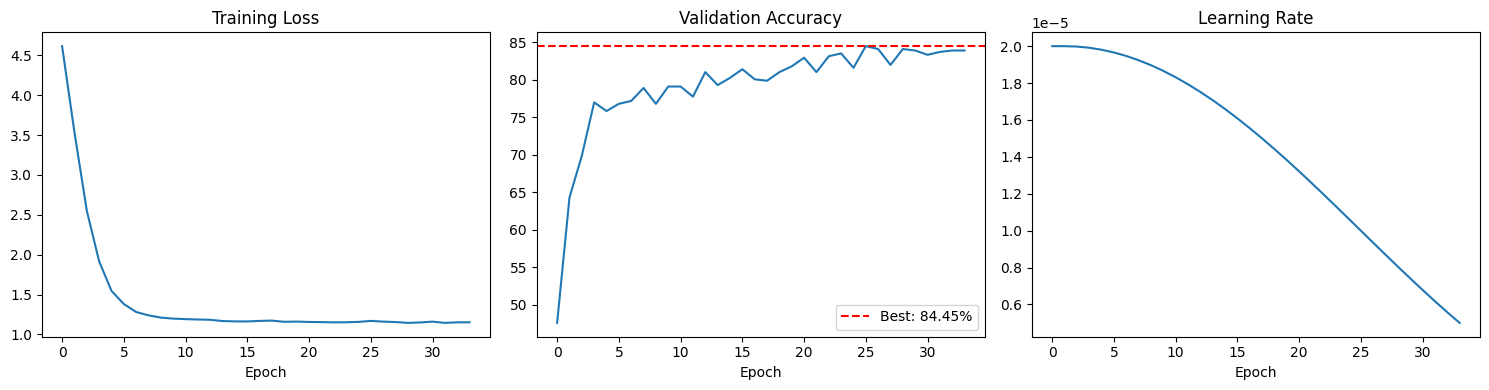

In [13]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'])
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')

axes[1].plot(history['val_acc'])
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].axhline(y=best_acc, color='r', linestyle='--', label=f'Best: {best_acc:.2f}%')
axes[1].legend()

axes[2].plot(history['lr'])
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_history.png', dpi=150)
plt.show()

In [14]:
# Load best model and evaluate on test set
checkpoint = torch.load(SAVE_DIR / 'clip_v2_best.pth')
model.load_state_dict(checkpoint['model'])

test_acc, preds, labels = evaluate(model, test_dl)

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"Baseline (untrained):     {zero_shot_acc:.2f}%")
print(f"Fine-tuned CLIP V2:       {test_acc:.2f}%")
print(f"Classes:                  {num_classes}")
print(f"Test samples:             {len(test)}")
print(f"Model:                    {CONFIG['clip_model']}")


FINAL RESULTS
Baseline (untrained):     0.81%
Fine-tuned CLIP V2:       80.21%
Classes:                  110
Test samples:             869
Model:                    ViT-L-14


In [15]:
# Top-5 accuracy
@torch.no_grad()
def top_k_accuracy(model, dl, k=5):
    model.eval()
    correct = total = 0
    for imgs, labels in dl:
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast(enabled=CONFIG['use_amp']):
            logits = model(imgs)
        _, topk = logits.topk(k, dim=1)
        correct += topk.eq(labels.view(-1, 1)).sum().item()
        total += labels.size(0)
    return 100 * correct / total

top5_acc = top_k_accuracy(model, test_dl, k=5)
print(f"\nTop-5 Accuracy: {top5_acc:.2f}%")


Top-5 Accuracy: 88.72%


In [16]:
# Inference function
def predict(image_path, top_k=5):
    model.eval()
    img = preprocess(Image.open(image_path).convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad(), autocast(enabled=CONFIG['use_amp']):
        logits = model(img)
        probs = logits.softmax(dim=-1)[0]
        topk = probs.topk(top_k)
    
    results = []
    for prob, idx in zip(topk.values, topk.indices):
        results.append((class_names[idx], prob.item() * 100))
    return results

# Test on a sample
sample_path = test.iloc[0]['path']
true_label = test.iloc[0]['class']
predictions = predict(sample_path)

print(f"\nSample prediction:")
print(f"True label: {true_label}")
print("Top-5 predictions:")
for name, prob in predictions:
    marker = "✓" if name == true_label else " "
    print(f"  {marker} {name}: {prob:.1f}%")


Sample prediction:
True label: Temple_of_Kom_Ombo
Top-5 predictions:
  ✓ Temple_of_Kom_Ombo: 73.7%
    Madrasah_of_Sarghatmish: 0.5%
    KV17: 0.5%
    Karnak_precinct_of_Amun-Ra: 0.5%
    6_October_Bridge: 0.4%


In [17]:
# Per-class accuracy analysis
from collections import defaultdict

class_correct = defaultdict(int)
class_total = defaultdict(int)

for pred, label in zip(preds, labels):
    class_total[label] += 1
    if pred == label:
        class_correct[label] += 1

class_acc = {class_names[i]: 100 * class_correct[i] / class_total[i] 
             for i in range(num_classes) if class_total[i] > 0}

sorted_acc = sorted(class_acc.items(), key=lambda x: x[1])
print("\nWorst performing classes:")
for name, acc in sorted_acc[:10]:
    print(f"  {name}: {acc:.0f}%")

print("\nBest performing classes:")
for name, acc in sorted_acc[-10:]:
    print(f"  {name}: {acc:.0f}%")


Worst performing classes:
  Edfu_Temple: 0%
  Theban_Necropolis: 0%
  Dendera_Temple_complex: 25%
  Qaed_Ibrahim_Mosque: 25%
  KV17: 33%
  Kom_el-Shoqafa: 33%
  Monastery_of_Saint_Anthony: 33%
  Temple_of_Seti_I_in_Abydos: 33%
  Gayer-Anderson_Museum: 38%
  Wadi_el_Gemal_National_Park: 40%

Best performing classes:
  Pompey's_Pillar,_Alexandria: 100%
  Pyramid_of_Menkaure: 100%
  Pyramid_of_Unas: 100%
  Qasr_al-Nil_Bridge: 100%
  Sphinx_of_Memphis: 100%
  Temple_of_Isis_in_Philae: 100%
  Tomb_of_Unknown_Soldier_in_Cairo: 100%
  Unfinished_obelisk_in_Aswan: 100%
  Wadi_el-Raiyan: 100%
  White_Monastery: 100%


In [18]:
print("\nModel saved to:", SAVE_DIR / 'clip_v2_best.pth')


Model saved to: /kaggle/working/clip_egypt_models_v2/clip_v2_best.pth
